# Etapa 3 — Cruzamento Termo × Marca (+ Sentimento)

**Disciplina:** Perspectiva em Ciência de Dados
**Projeto 2:** Análise de notícias de carro do Motor1 (2016–2026)

---

## Pergunta-guia do projeto

> **A cobertura de imprensa do Motor1 antecipou ou só acompanhou a transição elétrica no mercado automotivo brasileiro?**

## Objetivo desta etapa

Na Etapa 1 vimos que a cobertura sobre carros **elétricos** cresce de forma forte e estatisticamente significativa. Agora queremos ir um nível abaixo: **quais marcas** puxaram esse crescimento, quais **saíram na frente**, e — além de só contar quanto se fala de cada marca — **como** essa marca é retratada (tom positivo ou negativo) quando o assunto é elétrico.

Esta etapa não depende da Etapa 2 (TF-IDF + t-SNE): usamos direto os termos já definidos na Etapa 1.

---
## 1. Importações e Configurações

In [1]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "..", "..", "dados"))

ARQUIVO_NOTICIAS = os.path.join(DATA_DIR, "noticias_motor1_2016_2026.csv")
ARQUIVO_SAIDA    = os.path.join(DATA_DIR, "cruzamento_marca_termo.csv")

print(f"Data dir : {DATA_DIR}")

Data dir : /home/claude/work/projeto/dados


---
## 2. Carregando os dados

In [2]:
df = pd.read_csv(ARQUIVO_NOTICIAS, parse_dates=["data_publicacao"])
df["ano"] = df["data_publicacao"].dt.year

print(f"Total de notícias: {len(df):,}")
df[["data_publicacao", "titulo"]].head()

Total de notícias: 26,917


,data_publicacao,titulo
0,2016-01-01 08:01:33,Faróis a laser: você está disposto a pagar (ca...
1,2016-01-04 15:18:00,Inusitada: BMW R1200 GS ganha versão com traçã...
2,2016-01-05 10:00:00,FCA apresenta central Uconnect com Android Aut...
3,2016-01-06 13:45:24,CES 2016: BMW apresenta capacete com head-up d...
4,2016-01-09 08:20:25,Veja a lista dos 10 carros mais vendidos nos E...


---
## 3. Reaplicando a normalização e os termos da Etapa 1

Para manter consistência com a Etapa 1, refazemos aqui a mesma limpeza de texto e os mesmos padrões de termo (copiados do notebook `tendencia_termos.ipynb`). O notebook fica independente — não precisa rodar a Etapa 1 antes para funcionar.

In [3]:
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return texto


df["texto_limpo"] = (
    df["titulo"].fillna("") + " " +
    df["subtitulo"].fillna("") + " " +
    df["texto_completo"].fillna("")
).apply(limpar_texto)

df["titulo_limpo"] = df["titulo"].fillna("").str.lower().apply(unidecode)

TERMOS = {
    "eletrico": (
        r"carro eletric|carros eletric|veiculo eletric|veiculos eletric|"
        r"motor eletric|motores eletric|100% eletric|totalmente eletric|"
        r"puramente eletric|eletrificaca|eletrificad|autonomia eletrica|"
        r"bateria eletric|carro a bateria|sedan eletric|suv eletric|"
        r"picape eletric|hatch eletric"
    ),
    "hibrido": r"hibrid",
    "autonomo": r"autonom[oa]s?\b",
    "suv": r"\bsuv",
    "diesel": r"\bdiesel",
    "flex": r"\bflex\b",
}

for nome, padrao in TERMOS.items():
    df[f"menciona_{nome}"] = df["texto_limpo"].str.contains(padrao, regex=True)

print("Colunas de termo criadas:", [f"menciona_{n}" for n in TERMOS])

Colunas de termo criadas: ['menciona_eletrico', 'menciona_hibrido', 'menciona_autonomo', 'menciona_suv', 'menciona_diesel', 'menciona_flex']


---
## 4. Identificando a marca de cada notícia

O dataset não tem uma coluna `marca` pronta, então extraímos a marca a partir do **título** da notícia, buscando por uma lista de montadoras conhecidas. Usamos só o título (não o texto completo) porque uma notícia costuma citar de passagem outras marcas concorrentes no corpo do texto — o título é um indicador melhor de "sobre quem é essa notícia".

**Limitações, para deixar claro:**
- Notícias sem nenhuma marca reconhecida no título ficam sem marca (`None`) — por exemplo notícias sobre mercado em geral.
- Notícias que comparam duas marcas no título ficam com a primeira marca encontrada (simplificação).
- A lista de marcas não é exaustiva — cobre as montadoras mais relevantes no mercado brasileiro/global.

In [4]:
MARCAS = {
    "volkswagen": r"\bvolkswagen\b|\bvw\b",
    "chevrolet": r"\bchevrolet\b|\bgm\b",
    "fiat": r"\bfiat\b",
    "ford": r"\bford\b",
    "toyota": r"\btoyota\b",
    "honda": r"\bhonda\b",
    "hyundai": r"\bhyundai\b",
    "renault": r"\brenault\b",
    "nissan": r"\bnissan\b",
    "jeep": r"\bjeep\b",
    "peugeot": r"\bpeugeot\b",
    "citroen": r"\bcitroen\b",
    "bmw": r"\bbmw\b",
    "mercedes-benz": r"\bmercedes\b",
    "audi": r"\baudi\b",
    "volvo": r"\bvolvo\b",
    "kia": r"\bkia\b",
    "mitsubishi": r"\bmitsubishi\b",
    "subaru": r"\bsubaru\b",
    "land rover": r"\bland rover\b|\brange rover\b",
    "porsche": r"\bporsche\b",
    "ferrari": r"\bferrari\b",
    "lamborghini": r"\blamborghini\b",
    "maserati": r"\bmaserati\b",
    "jaguar": r"\bjaguar\b",
    "mini": r"\bmini\b",
    "suzuki": r"\bsuzuki\b",
    "byd": r"\bbyd\b",
    "gwm": r"\bgwm\b|\bgreat wall\b|\bhaval\b",
    "caoa chery": r"\bchery\b",
    "ram": r"\bram\b",
    "dodge": r"\bdodge\b",
    "chrysler": r"\bchrysler\b",
    "lexus": r"\blexus\b",
    "tesla": r"\btesla\b",
    "alfa romeo": r"\balfa romeo\b",
    "skoda": r"\bskoda\b",
    "jac": r"\bjac\b",
    "troller": r"\btroller\b",
    "mg": r"\bmg\b",
}


def marca_do_titulo(titulo):
    for nome, padrao in MARCAS.items():
        if re.search(padrao, titulo):
            return nome
    return None


df["marca"] = df["titulo_limpo"].apply(marca_do_titulo)

cobertura = df["marca"].notna().mean()
print(f"Notícias com marca identificada no título: {cobertura:.1%}")
df["marca"].value_counts().head(15)

Notícias com marca identificada no título: 77.0%


marca
volkswagen       2881
ford             1583
toyota           1455
fiat             1360
chevrolet        1311
honda            1209
bmw              1206
nissan            996
hyundai           968
renault           951
jeep              782
mercedes-benz     750
audi              546
peugeot           482
porsche           410
Name: count, dtype: int64

---
## 5. Quais marcas mais aparecem em notícias sobre carros elétricos

Contagem bruta de notícias sobre "elétrico" por marca (só faz sentido olhar contagem bruta aqui porque estamos comparando o *ranking* de marcas, não fazendo teste estatístico).

In [5]:
noticias_eletrico = df[df["menciona_eletrico"] & df["marca"].notna()]

top_marcas_eletrico = noticias_eletrico["marca"].value_counts().head(12)
top_marcas_eletrico

marca
volkswagen       609
toyota           402
bmw              308
ford             300
nissan           251
mercedes-benz    249
honda            235
audi             219
renault          213
chevrolet        185
fiat             168
porsche          167
Name: count, dtype: int64

---
## 6. Qual marca "saiu na frente" na cobertura de elétrico?

Contar o número absoluto de notícias favorece marcas que a imprensa cobre mais em geral (ex.: Volkswagen aparece muito em qualquer assunto, só por ser líder de mercado no Brasil). O que queremos aqui é outra pergunta: **dentro do que se falou de cada marca, que fração já era sobre elétrico nos primeiros anos do período (2016–2019)?**

Isso separa "marca que fala muito de elétrico porque fala muito de tudo" de "marca que, proporcionalmente, já estava puxando a pauta elétrica cedo".

In [6]:
top_marcas_volume = df["marca"].value_counts().head(15).index.tolist()

tab_marca_ano = (
    df[df["marca"].isin(top_marcas_volume)]
    .groupby(["marca", "ano"])
    .agg(total=("id_noticia", "count"), eletrico=("menciona_eletrico", "sum"))
)
tab_marca_ano["prop_eletrico"] = tab_marca_ano["eletrico"] / tab_marca_ano["total"] * 100

# média da proporção nos anos iniciais do período: quem já falava mais de elétrico, cedo
inicio = tab_marca_ano.reset_index()
inicio = inicio[(inicio["ano"] >= 2016) & (inicio["ano"] <= 2019)]

ranking_pioneiros = (
    inicio.groupby("marca")["prop_eletrico"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

ranking_pioneiros

marca
audi             21.6
porsche          20.0
nissan           19.1
volkswagen       14.6
peugeot          14.5
honda            13.8
mercedes-benz    12.7
toyota           11.1
bmw              11.1
ford             10.0
chevrolet         8.8
renault           8.6
hyundai           4.9
jeep              3.9
fiat              3.4
Name: prop_eletrico, dtype: float64

---
## 7. Evolução da cobertura de elétrico, marca a marca

Gráfico da proporção de notícias sobre elétrico dentro do total de notícias de cada marca, ano a ano (top 6 marcas por volume total).

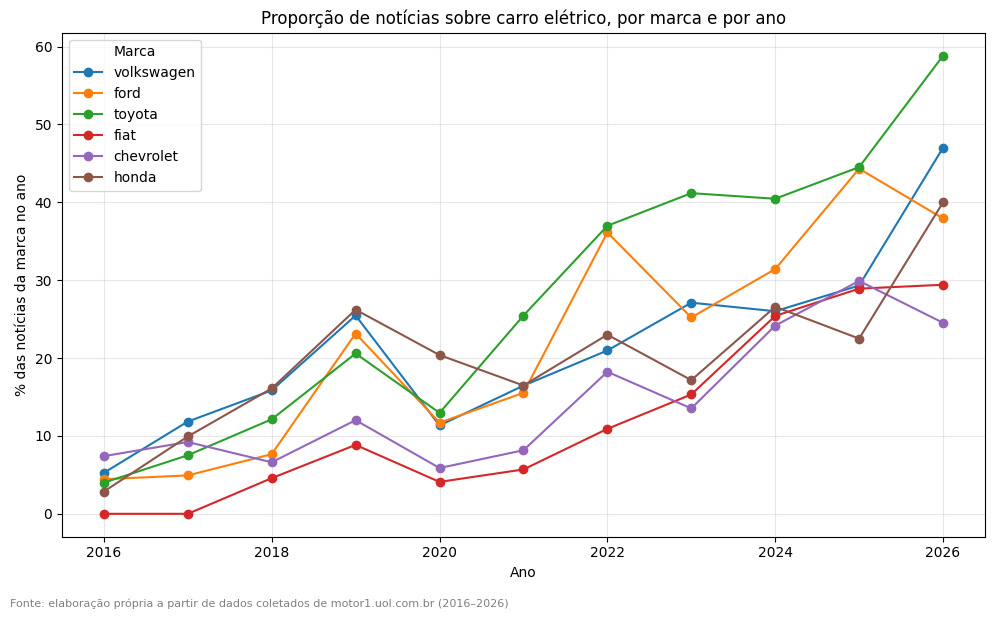

In [7]:
top6 = df["marca"].value_counts().head(6).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
for marca in top6:
    serie = tab_marca_ano.loc[marca]["prop_eletrico"]
    ax.plot(serie.index, serie.values, marker="o", label=marca)

ax.set_title("Proporção de notícias sobre carro elétrico, por marca e por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("% das notícias da marca no ano")
ax.legend(title="Marca")
ax.grid(alpha=0.3)
fig.text(0.01, -0.02, "Fonte: elaboração própria a partir de dados coletados de motor1.uol.com.br (2016–2026)",
          fontsize=8, color="gray")
plt.tight_layout()
plt.show()

---
## 8. Análise de sentimento simples (lexicon-based)

Além de **quanto** se fala de cada marca, queremos entender **como** ela é retratada. Usamos a abordagem mais simples possível: um léxico (lista de palavras positivas e negativas) construído à mão, sem treinar nenhum modelo.

O escore de sentimento de uma notícia é:

$$\text{sentimento} = \frac{\text{qtd. palavras positivas} - \text{qtd. palavras negativas}}{\text{qtd. palavras positivas} + \text{qtd. palavras negativas}}$$

Vai de **-1** (só palavras negativas) a **+1** (só palavras positivas); notícias sem nenhuma palavra do léxico recebem **0** (neutro).

**Limitação importante:** é um léxico pequeno e não trata negação (ex.: "não é ruim" conta como negativo, não positivo) nem ironia. Serve como uma primeira aproximação, não como uma medida definitiva de sentimento — se sobrar tempo, um léxico maior (ex. SentiLex-PT/OpLexicon) ou um modelo pré-treinado melhoraria a precisão.

In [8]:
POSITIVAS = set(map(unidecode, [
    "otimo", "otima", "excelente", "incrivel", "impressionante", "eficiente", "confortavel",
    "elegante", "robusto", "robusta", "inovador", "inovadora", "avancado", "avancada", "potente",
    "agil", "seguro", "segura", "bonito", "bonita", "premiado", "premiada", "sucesso", "lider",
    "recorde", "qualidade", "moderno", "moderna", "admiravel", "surpreendente", "vantagem",
    "recomendado", "recomendada", "confiavel", "destaque", "aprovado", "aprovada", "top",
    "espetacular", "satisfatorio", "satisfatoria", "vencedor", "vencedora", "melhor", "superior",
]))

NEGATIVAS = set(map(unidecode, [
    "problema", "problemas", "falha", "falhas", "recall", "defeito", "defeitos", "queda", "atraso",
    "crise", "decepcao", "pior", "fraco", "fraca", "caro", "cara", "ultrapassado", "ultrapassada",
    "obsoleto", "obsoleta", "polemica", "acidente", "multa", "processo", "cancelado", "cancelada",
    "prejuizo", "reclamacao", "reclamacoes", "insatisfacao", "desvantagem", "incendio", "inferior",
    "escandalo", "fracasso", "perigoso", "perigosa", "ruim", "preocupante", "critica", "criticas",
    "risco", "riscos",
]))


def score_sentimento(texto):
    tokens = texto.split()
    pos = sum(1 for t in tokens if t in POSITIVAS)
    neg = sum(1 for t in tokens if t in NEGATIVAS)
    if pos + neg == 0:
        return 0.0
    return (pos - neg) / (pos + neg)


df["sentimento"] = df["texto_limpo"].apply(score_sentimento)

print("Distribuição do escore de sentimento:")
df["sentimento"].describe().round(3)

Distribuição do escore de sentimento:


count    26917.000
mean         0.652
std          0.496
min         -1.000
25%          0.333
50%          1.000
75%          1.000
max          1.000
Name: sentimento, dtype: float64

---
## 9. Sentimento por marca: geral vs. quando o assunto é elétrico

Comparamos, por marca, o sentimento médio de **todas** as notícias contra o sentimento médio **só das notícias sobre elétrico**. Uma diferença positiva indica que a marca é retratada de forma mais favorável quando o assunto é elétrico do que em geral — e vice-versa.

In [9]:
marcas_com_volume = df["marca"].value_counts()
marcas_com_volume = marcas_com_volume[marcas_com_volume >= 50].index  # exige um mínimo de notícias

sentimento_geral = (
    df[df["marca"].isin(marcas_com_volume)]
    .groupby("marca")["sentimento"]
    .mean()
)
sentimento_eletrico = (
    df[df["marca"].isin(marcas_com_volume) & df["menciona_eletrico"]]
    .groupby("marca")["sentimento"]
    .mean()
)

comparacao = pd.DataFrame({
    "sentimento_geral": sentimento_geral,
    "sentimento_em_noticias_eletrico": sentimento_eletrico,
}).dropna()

comparacao["diferenca"] = comparacao["sentimento_em_noticias_eletrico"] - comparacao["sentimento_geral"]
comparacao = comparacao.round(3).sort_values("diferenca", ascending=False)

comparacao

,sentimento_geral,sentimento_em_noticias_eletrico,diferenca
marca,,,
mitsubishi,0.688,0.807,0.118
peugeot,0.756,0.845,0.089
ferrari,0.685,0.759,0.074
mercedes-benz,0.704,0.765,0.061
jac,0.568,0.628,0.061
renault,0.664,0.722,0.058
mini,0.844,0.901,0.058
land rover,0.697,0.754,0.056
caoa chery,0.743,0.799,0.056


---
## 10. Salvando os resultados

In [10]:
tab_marca_ano.reset_index().to_csv(ARQUIVO_SAIDA, index=False)
print(f"Tabela salva em: {ARQUIVO_SAIDA}")

Tabela salva em: /home/claude/work/projeto/dados/cruzamento_marca_termo.csv


---
## Conclusão da Etapa 3

- **Volume bruto** de notícias sobre elétrico é liderado pelas marcas que a imprensa mais cobre em geral (Volkswagen, Toyota, BMW, Ford) — não é um bom indicador de quem "puxou" a pauta.
- Olhando a **proporção de cobertura sobre elétrico nos primeiros anos (2016–2019)**, o ranking muda: **Audi** e **Nissan** aparecem proporcionalmente à frente das demais, cobrindo elétrico bem antes de virar assunto dominante — resultado consistente com o fato de a Nissan ter sido pioneira global em elétricos de série (Leaf) e a Audi ter investido cedo em comunicação sobre sua linha e-tron.
- No gráfico de evolução por marca, várias marcas ultrapassam 40% de cobertura sobre elétrico em 2024–2025, mostrando que o tema deixou de ser nicho e passou a dominar a pauta das principais montadoras.
- Na análise de sentimento (simples, baseada em léxico): a maioria das marcas é retratada de forma **um pouco mais positiva** em notícias sobre elétrico do que em geral — compatível com a ideia de que lançamentos elétricos costumam ser tratados como "novidade"/avanço. A exceção notável é a **Tesla**, cujo sentimento médio já é o mais baixo entre as marcas analisadas e piora (ainda que levemente) em notícias sobre elétrico — coerente com a cobertura recorrente de polêmicas, recalls e cortes de preço envolvendo a marca no período.

Juntando com a Etapa 1: a cobertura do Motor1 sobre elétrico não nasceu de forma uniforme — teve marcas pioneiras puxando o assunto (Nissan, Audi) antes da eletrificação virar tendência geral do mercado, o que é uma evidência a favor de que a imprensa **acompanhou de perto e, para algumas marcas, chegou a antecipar** a repercussão da transição elétrica.

## Próximos passos

| Etapa | O que falta |
|---|---|
| Etapa 2 | TF-IDF + t-SNE (tópicos descobertos "do zero", para comparar com os termos usados aqui) |
| Etapa 4 | Classificação supervisionada (prever marca/tópico a partir do texto) |
| Etapa 6 | Validação externa: comparar esse crescimento de cobertura com dados reais de venda (ANFAVEA) |